## Реализуйте классическую нейронную сеть для задачи многоклассовой классификации точек на плоскости на четыре класса. Точность классификации должна быть больше 0.9 на тестовой выборке.

## 1. Импорт библиотек

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Для воспроизводимости
np.random.seed(42)
torch.manual_seed(42)

## 2. Создание и визуализация датасета

Создадим искусственный датасет из восьми классов точек на плоскости:

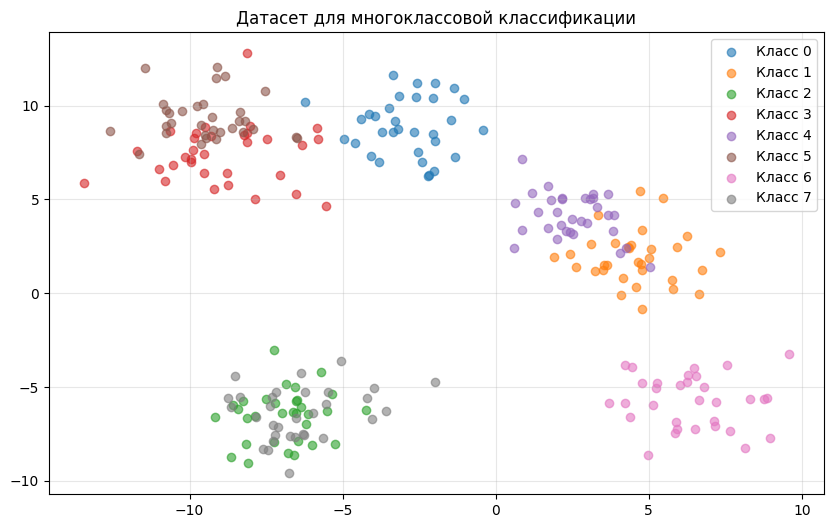

Размер обучающей выборки: (192, 2)
Размер тестовой выборки: (64, 2)
Распределение классов: [32 32 32 32 32 32 32 32]


In [7]:
# Создаем датасет с восемью классами
n_samples = 256 # Кол-во точек
n_features = 2 # Кол-во координат (признаков)
n_classes = 8

X, y = make_blobs( # X - матрица признаков, y - вектор ответов от 0 до 3
    n_samples=n_samples,
    n_features=n_features,
    centers=n_classes,
    cluster_std=1.42,
    random_state=42
)

# Масштабируем данные в диапазон [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Преобразуем метки в one-hot encoding
y_onehot = np.eye(n_classes)[y]

# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test, y_train_labels, y_test_labels = train_test_split(
    X_scaled, y_onehot, y, test_size=0.25, random_state=42
)

# Визуализация датасета
plt.figure(figsize=(10, 6))
for i in range(n_classes):
    plt.scatter(X[y == i, 0], X[y == i, 1], 
                alpha=0.6, label=f'Класс {i}')

plt.title("Датасет для многоклассовой классификации")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов: {np.bincount(y)}")

## 5. Создание модели PyTorch

In [8]:
class ClassicalModel(nn.Module): # Наследуемся от nn.Module
    def __init__(self, input_dim=n_features, output_dim=n_classes): # 2 признака, 4 - кол-во классов
        super(ClassicalModel, self).__init__()

        self.input_dim = input_dim
        self.output_dim = output_dim
        #Пример нужно заменить на ваши слои
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, output_dim)
        )
    
    def forward(self, x):
        x = self.network(x)

        return x

    def predict_proba(self, x):
        """Возвращает вероятности классов"""
        with torch.no_grad():
            log_probs = self.forward(x)
            return torch.exp(log_probs)

    def predict(self, x):
        """Возвращает предсказанные классы"""
        with torch.no_grad():
            log_probs = self.forward(x)
            return torch.argmax(log_probs, dim=1)

model = ClassicalModel(input_dim=n_features, output_dim=n_classes)

print("Архитектура модели:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {total_params}")
print(f"Обучаемых параметров: {trainable_params}")

Архитектура модели:
ClassicalModel(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=8, bias=True)
  )
)

Всего параметров: 4872
Обучаемых параметров: 4872


## 6. Подготовка данных для PyTorch

In [9]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_labels, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_labels, dtype=torch.long)

# Создаем DataLoader
batch_size = 1 # Размер батча
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Размер батча: {batch_size}")
print(f"Количество батчей в обучающей выборке: {len(train_loader)}")
print(f"Количество батчей в тестовой выборке: {len(test_loader)}")

Размер батча: 1
Количество батчей в обучающей выборке: 192
Количество батчей в тестовой выборке: 64


## 7. Обучение модели

In [10]:
def train_model(model, train_loader, test_loader, epochs=50, learning_rate=0.01):
    """
    Обучает гибридную модель.
    """
    # Функция потерь и оптимизатор
    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # Для отслеживания метрик
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []
    
    print("Начинаем обучение...")
    
    for epoch in range(epochs):
        # Режим обучения
        model.train()
        total_train_loss = 0
        train_correct = 0
        train_total = 0
        
        for _, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            
            # Прямой проход
            output = model(data)
            loss = loss_function(output, target)
            
            # Обратный проход
            loss.backward()
            optimizer.step()
            
            # Считаем метрики
            total_train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        # Средняя потеря и точность на обучающей выборке
        avg_train_loss = total_train_loss / len(train_loader)
        train_accuracy = 100 * train_correct / train_total
        
        # Оценка на тестовой выборке
        model.eval()
        total_test_loss = 0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                output = model(data)
                loss = loss_function(output, target)
                total_test_loss += loss.item()
                
                _, predicted = torch.max(output.data, 1)
                test_total += target.size(0)
                test_correct += (predicted == target).sum().item()
        
        # Средняя потеря и точность на тестовой выборке
        avg_test_loss = total_test_loss / len(test_loader)
        test_accuracy = 100 * test_correct / test_total

        train_losses.append(avg_train_loss)
        train_accuracies.append(train_accuracy)
        test_losses.append(avg_test_loss)
        test_accuracies.append(test_accuracy)

        clear_output(wait=True)
        print(f"Эпоха {epoch+1}/{epochs}:")
        print(f"  Обучающая выборка: loss={avg_train_loss:.4f}, accuracy={train_accuracy:.2f}%")
        print(f"  Тестовая выборка:  loss={avg_test_loss:.4f}, accuracy={test_accuracy:.2f}%")
    
    print("\nОбучение завершено!")
    
    return train_losses, train_accuracies, test_losses, test_accuracies

epochs = 45 # Количество эпох обучения (можно изменять)
learning_rate = 0.001 # Скорость обучения (можно изменять)

train_losses, train_accuracies, test_losses, test_accuracies = train_model(
    model, train_loader, test_loader, epochs=epochs, learning_rate=learning_rate
)

Эпоха 45/45:
  Обучающая выборка: loss=0.4147, accuracy=77.60%
  Тестовая выборка:  loss=0.3911, accuracy=82.81%

Обучение завершено!


## 8. Визуализация процесса обучения

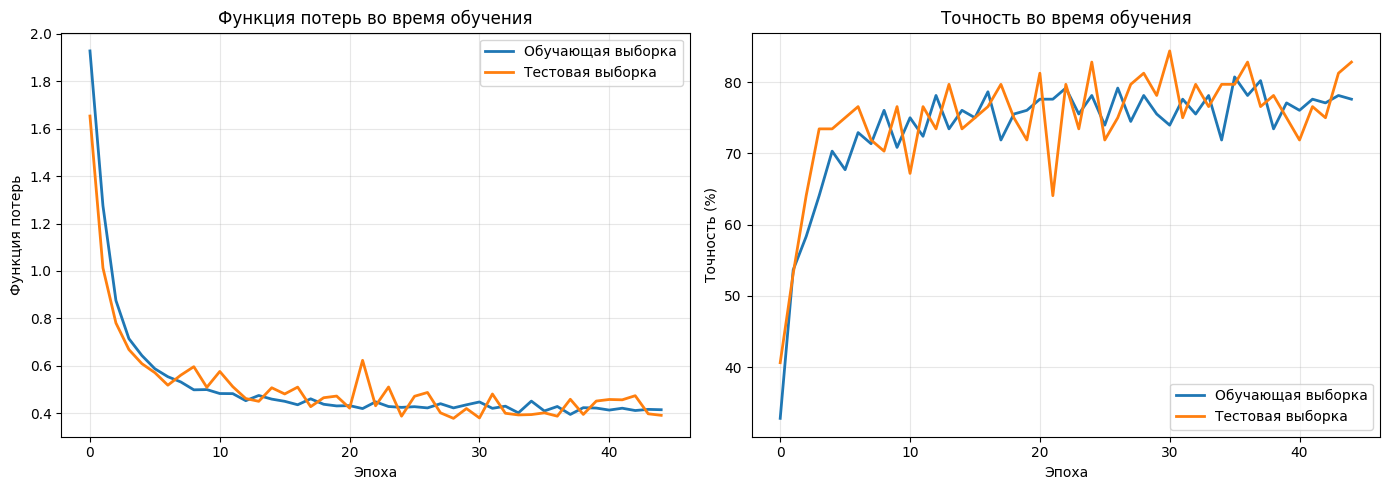

Финальная точность на обучающей выборке: 77.60%
Финальная точность на тестовой выборке: 82.81%


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label='Обучающая выборка', linewidth=2)
axes[0].plot(test_losses, label='Тестовая выборка', linewidth=2)
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Функция потерь')
axes[0].set_title('Функция потерь во время обучения')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_accuracies, label='Обучающая выборка', linewidth=2)
axes[1].plot(test_accuracies, label='Тестовая выборка', linewidth=2)
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Точность (%)')
axes[1].set_title('Точность во время обучения')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Финальная точность на обучающей выборке: {train_accuracies[-1]:.2f}%")
print(f"Финальная точность на тестовой выборке: {test_accuracies[-1]:.2f}%")

## 9. Оценка модели

Результаты классификации:
Точность на тестовой выборке: 82.81%


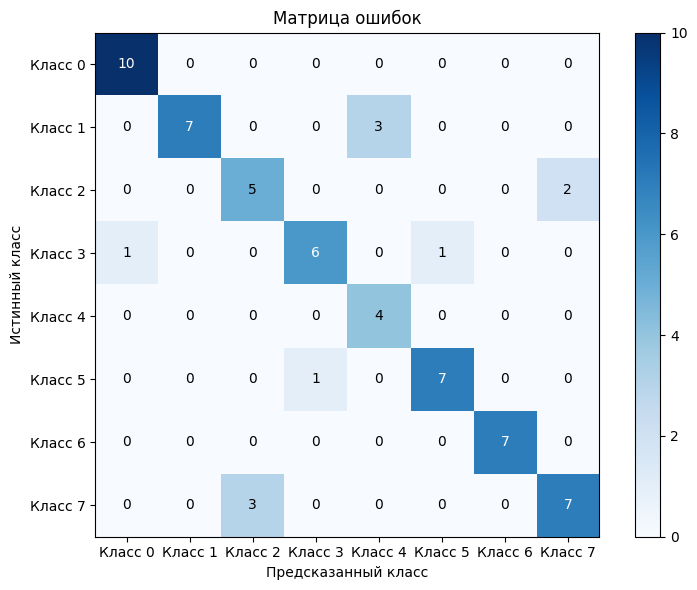


Отчет о классификации:
              precision    recall  f1-score   support

     Класс 0       0.91      1.00      0.95        10
     Класс 1       1.00      0.70      0.82        10
     Класс 2       0.62      0.71      0.67         7
     Класс 3       0.86      0.75      0.80         8
     Класс 4       0.57      1.00      0.73         4
     Класс 5       0.88      0.88      0.88         8
     Класс 6       1.00      1.00      1.00         7
     Класс 7       0.78      0.70      0.74        10

    accuracy                           0.83        64
   macro avg       0.83      0.84      0.82        64
weighted avg       0.85      0.83      0.83        64



In [12]:
model.eval()

with torch.no_grad():
    y_pred = model.predict(X_test_tensor)
    y_pred_proba = model.predict_proba(X_test_tensor)

accuracy = (y_pred.numpy() == y_test_labels).mean()

print("Результаты классификации:")
print(f"Точность на тестовой выборке: {accuracy:.2%}")

# Матрица ошибок
cm = confusion_matrix(y_test_labels, y_pred.numpy())

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Матрица ошибок')
plt.colorbar()

tick_marks = np.arange(n_classes)
plt.xticks(tick_marks, [f'Класс {i}' for i in range(n_classes)])
plt.yticks(tick_marks, [f'Класс {i}' for i in range(n_classes)])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

print("\nОтчет о классификации:")
print(classification_report(y_test_labels, y_pred.numpy(), 
                           target_names=[f'Класс {i}' for i in range(n_classes)]))

## 10. Визуализация границ решения

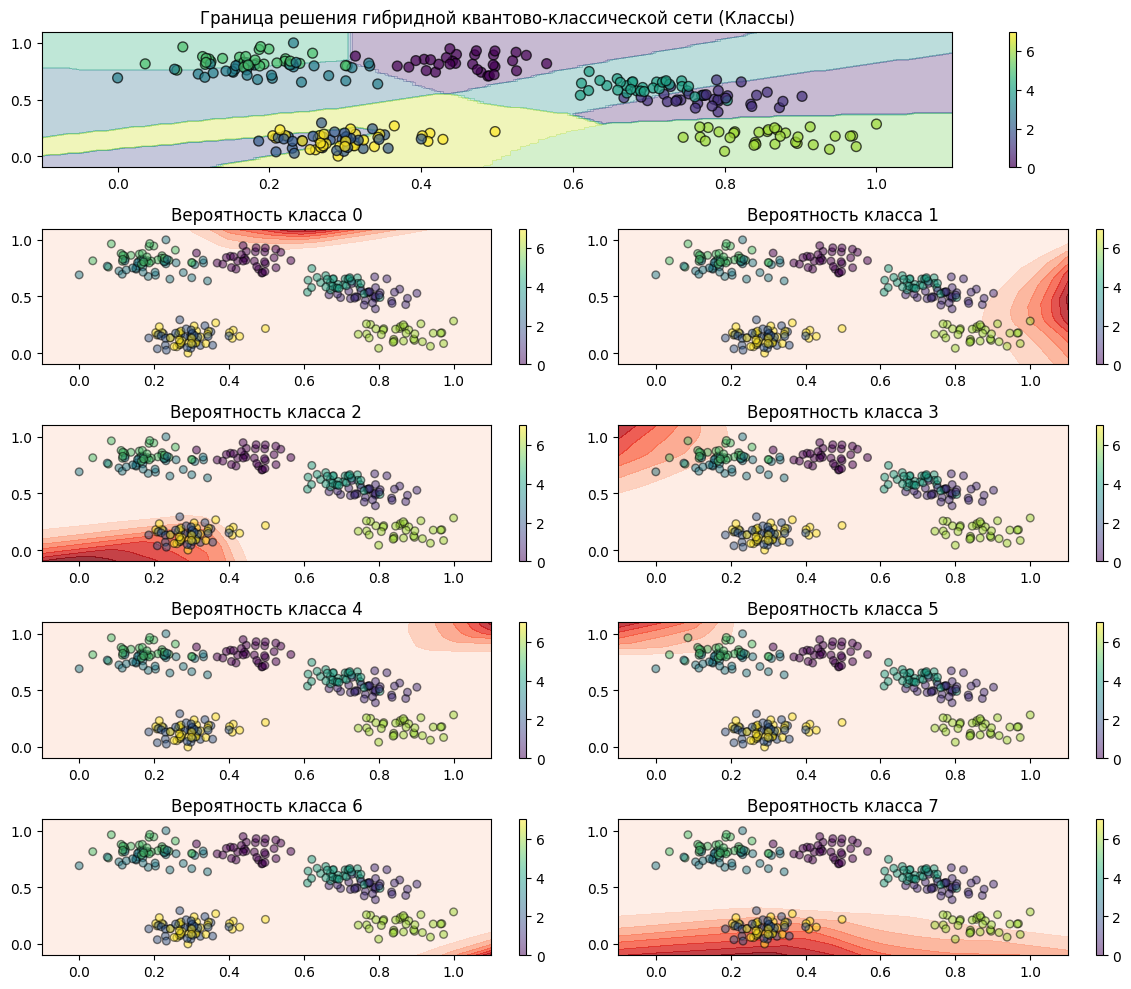

In [13]:
def plot_decision_boundary(model, X, y, title="Граница решения классификатора"):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32)
    
    with torch.no_grad():
        Z = model.predict(grid_tensor)
        Z_proba = model.predict_proba(grid_tensor)
        
    Z = Z.numpy().reshape(xx.shape)

    plt.figure(figsize=(12, 10))

    plt.subplot(1 + n_classes//2, 2, (1, 2))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                          edgecolors='k', s=50, alpha=0.7)
    plt.title(title + ' (Классы)')
    plt.colorbar(scatter)

    for i in range(n_classes):
        plt.subplot(1 + n_classes//2, 2, i + 3)
        Z_proba_class = Z_proba[:, i].numpy().reshape(xx.shape)
        plt.contourf(xx, yy, Z_proba_class, alpha=0.8, cmap='Reds')
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', 
                   edgecolors='k', s=30, alpha=0.5)
        plt.title(f'Вероятность класса {i}')
        plt.colorbar()
    
    plt.tight_layout()
    plt.show()

# Визуализация на полном датасете
plot_decision_boundary(model, X_scaled, y, 
                       title="Граница решения гибридной квантово-классической сети")